In [8]:
# Replacement Complexity as a Summary Statistic
# Motivation 
# A practical audit should summarize nonlinearity into an actionable resource signal. We define the minimal kernel budget needed to pass a tolerance threshold and evaluate whether this summary preserves target ordering.  

# $$
# B_t(\tau):=\inf\{\Lambda:U_t^{\mathrm{ker}}(\Lambda)\le \tau\},
# $$
# $$
# U_t^{\mathrm{ker}}(\Lambda)=\mathbb{E}_{(x,\theta)\in P_{\mathrm{eval}}}\left[\left|Y_t-h^*_{\Lambda}(\Phi_{-t})\right|\right].
# $$

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "figure.figsize": (7, 4.5),
    "figure.dpi": 150,
    "mathtext.fontset": "dejavuserif"
})

from pathlib import Path
import numpy as np
import pandas as pd
art_dir = Path('../results/artifacts').resolve()
art_dir.mkdir(parents=True, exist_ok=True)

In [9]:
csv_path = Path('../results/tables/exp2_replacement_complexity.csv').resolve()
df = pd.read_csv(csv_path)
reachable = df[df['reachable'] == 1].copy()
rho = reachable[['true_complexity', 'B_tau']].corr(method='spearman').iloc[0, 1]
df.head()

,target_id,true_complexity,tau,lambda_star,B_tau,pier_at_B_tau,reachable,gamma,n_fit,n_eval,n_peers,honesty_fit_size,honesty_eval_size
0,0,0.05,0.2,0.1,10.0,0.035310,1,0.033934,260,360,8,260,360
1,1,0.10,0.2,0.1,10.0,0.039659,1,0.033934,260,360,8,260,360
2,2,0.15,0.2,0.1,10.0,0.049768,1,0.033934,260,360,8,260,360
3,3,0.20,0.2,0.1,10.0,0.063085,1,0.033934,260,360,8,260,360
4,4,0.25,0.2,0.1,10.0,0.077977,1,0.033934,260,360,8,260,360


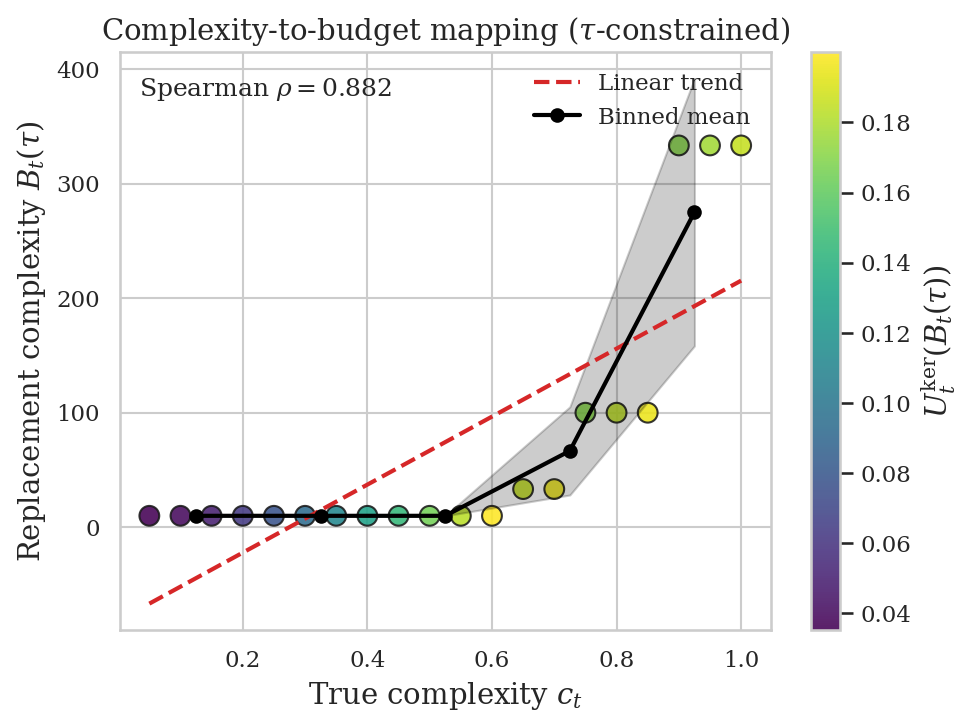

In [10]:
# figure: complexity-to-budget mapping
# Scatter plots display individual data points, while linear trends provide visual guidance; box plots are accompanied by shaded areas representing the mean ± standard deviation.

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    reachable['true_complexity'],
    reachable['B_tau'],
    c=reachable['pier_at_B_tau'],
    cmap='viridis',
    s=90,
    edgecolor='k',
    alpha=0.88,
)
ax.set_xlabel(r'True complexity $c_t$')
ax.set_ylabel(r'Replacement complexity $B_t(\tau)$')
ax.set_title(r'Complexity-to-budget mapping ($\tau$-constrained)')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label(r'$U_t^{\mathrm{ker}}(B_t(\tau))$')

if len(reachable) >= 2:
    x = reachable['true_complexity'].values
    y = reachable['B_tau'].values
    coef = np.polyfit(x, y, deg=1)
    xx = np.linspace(x.min(), x.max(), 100)
    yy = coef[0] * xx + coef[1]
    ax.plot(xx, yy, '--', color='tab:red', lw=2, label='Linear trend')

bins = pd.qcut(reachable['true_complexity'], q=min(5, len(reachable)), duplicates='drop')
band = reachable.groupby(bins, observed=True).agg(x=('true_complexity', 'mean'), y=('B_tau', 'mean'), s=('B_tau', 'std')).dropna()
if len(band) > 1:
    bx = band['x'].to_numpy()
    by = band['y'].to_numpy()
    bs = band['s'].fillna(0.0).to_numpy()
    ax.plot(bx, by, color='black', lw=2.0, marker='o', label='Binned mean')
    ax.fill_between(bx, by - bs, by + bs, alpha=0.2, color='black')

ax.legend(loc='best')
ax.text(0.03, 0.96, rf'Spearman $\rho={rho:.3f}$', transform=ax.transAxes, va='top')

plt.savefig(art_dir / 'exp2_replacement_complexity.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [11]:
# Summary statistics: Provide the sample size, the proportion of cases reached, and the correlation coefficient; these serve as supporting evidence for the textual description in the paper.
summary = {
    'n_targets': int(len(df)),
    'n_reachable': int((df['reachable'] == 1).sum()),
    'tau': float(df['tau'].iloc[0]),
    'spearman_corr_complexity_vs_Btau': float(rho) if len(reachable) >= 2 else np.nan,
}
summary

{'n_targets': 20,
 'n_reachable': 20,
 'tau': 0.2,
 'spearman_corr_complexity_vs_Btau': 0.8821538917455414}

In [12]:
hard_csv_path = Path('../results/tables/exp2_replacement_complexity_hard.csv').resolve()
df_hard = pd.read_csv(hard_csv_path)
reachable_hard = df_hard[df_hard['reachable'] == 1].copy()

# sanity check
print('hard table shape:', df_hard.shape)
print('peer_complexity levels:', sorted(df_hard['peer_complexity'].unique()))


hard table shape: (60, 14)
peer_complexity levels: ['high', 'low', 'medium']


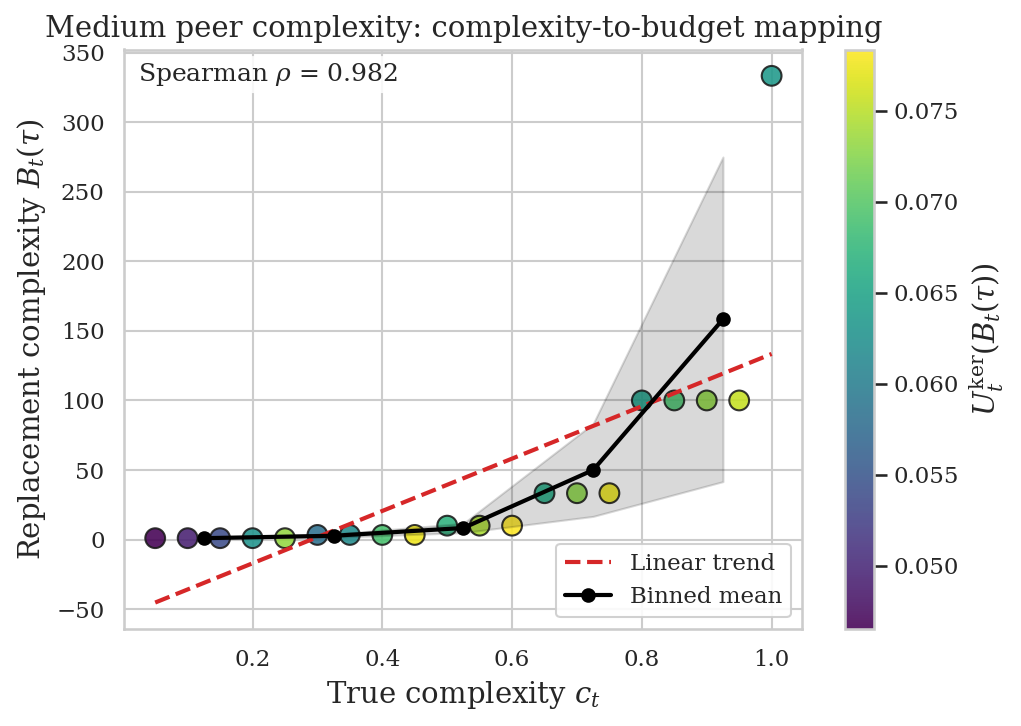

saved: /Users/zsh/GITHUBPROJECTS/KnernelIsqed/results/artifacts/exp2_replacement_complexity_hard_medium.pdf


In [13]:
# Medium peer complexity (hard extension)

medium = reachable_hard[reachable_hard['peer_complexity'] == 'medium'].copy()
rho_medium = medium[['true_complexity', 'B_tau']].corr(method='spearman').iloc[0, 1] if len(medium) >= 2 else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    medium['true_complexity'],
    medium['B_tau'],
    c=medium['pier_at_B_tau'],
    cmap='viridis',
    s=90,
    edgecolor='k',
    alpha=0.88,
)
ax.set_xlabel(r'True complexity $c_t$')
ax.set_ylabel(r'Replacement complexity $B_t(\tau)$')
ax.set_title(r'Medium peer complexity: complexity-to-budget mapping')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label(r'$U_t^{\mathrm{ker}}(B_t(\tau))$')

if len(medium) >= 2:
    x = medium['true_complexity'].values
    y = medium['B_tau'].values
    coef = np.polyfit(x, y, deg=1)
    xx = np.linspace(x.min(), x.max(), 100)
    yy = coef[0] * xx + coef[1]
    ax.plot(xx, yy, '--', color='tab:red', lw=2, label='Linear trend')

bins = pd.qcut(medium['true_complexity'], q=min(5, len(medium)), duplicates='drop')
band = medium.groupby(bins, observed=True).agg(x=('true_complexity', 'mean'), y=('B_tau', 'mean'), s=('B_tau', 'std')).dropna()
if len(band) > 1:
    bx = band['x'].to_numpy()
    by = band['y'].to_numpy()
    bs = band['s'].fillna(0.0).to_numpy()
    ax.plot(bx, by, color='black', lw=2.0, marker='o', label='Binned mean')
    ax.fill_between(bx, by - bs, by + bs, alpha=0.15, color='black')

ax.text(0.02, 0.98, rf'Spearman $\rho$ = {rho_medium:.3f}', transform=ax.transAxes, va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.2'))
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

out_path = art_dir / 'exp2_replacement_complexity_hard_medium.pdf'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print('saved:', out_path)


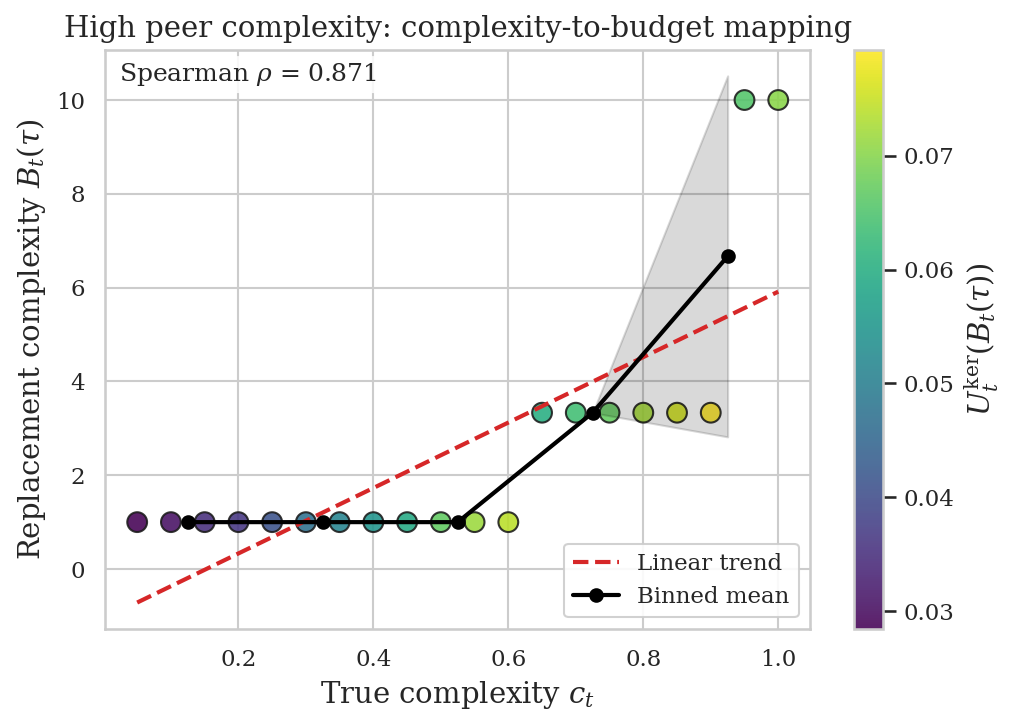

saved: /Users/zsh/GITHUBPROJECTS/KnernelIsqed/results/artifacts/exp2_replacement_complexity_hard_high.pdf


In [14]:
# High peer complexity

high = reachable_hard[reachable_hard['peer_complexity'] == 'high'].copy()
rho_high = high[['true_complexity', 'B_tau']].corr(method='spearman').iloc[0, 1] if len(high) >= 2 else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    high['true_complexity'],
    high['B_tau'],
    c=high['pier_at_B_tau'],
    cmap='viridis',
    s=90,
    edgecolor='k',
    alpha=0.88,
)
ax.set_xlabel(r'True complexity $c_t$')
ax.set_ylabel(r'Replacement complexity $B_t(\tau)$')
ax.set_title(r'High peer complexity: complexity-to-budget mapping')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label(r'$U_t^{\mathrm{ker}}(B_t(\tau))$')

if len(high) >= 2:
    x = high['true_complexity'].values
    y = high['B_tau'].values
    coef = np.polyfit(x, y, deg=1)
    xx = np.linspace(x.min(), x.max(), 100)
    yy = coef[0] * xx + coef[1]
    ax.plot(xx, yy, '--', color='tab:red', lw=2, label='Linear trend')

bins = pd.qcut(high['true_complexity'], q=min(5, len(high)), duplicates='drop')
band = high.groupby(bins, observed=True).agg(x=('true_complexity', 'mean'), y=('B_tau', 'mean'), s=('B_tau', 'std')).dropna()
if len(band) > 1:
    bx = band['x'].to_numpy()
    by = band['y'].to_numpy()
    bs = band['s'].fillna(0.0).to_numpy()
    ax.plot(bx, by, color='black', lw=2.0, marker='o', label='Binned mean')
    ax.fill_between(bx, by - bs, by + bs, alpha=0.15, color='black')

ax.text(0.02, 0.98, rf'Spearman $\rho$ = {rho_high:.3f}', transform=ax.transAxes, va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.2'))
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

out_path = art_dir / 'exp2_replacement_complexity_hard_high.pdf'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print('saved:', out_path)
